In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

In [2]:
import pandas as pd

# Load Pushkar's scores
pushkar_df = pd.read_csv('../../reports/model_scores_for_comparison.csv')
if_scores = pushkar_df['iso_forest_score'].values
svm_scores = pushkar_df['oc_svm_score'].values
y_test_pushkar = pushkar_df['true_label'].values

# Load Aakash's autoencoder scores
ae_scores = np.load('../../reports/ae_scores.npy')
y_test = np.load('../../reports/y_test_real.npy')

print(f"Isolation Forest scores loaded: {len(if_scores)}")
print(f"OC-SVM scores loaded: {len(svm_scores)}")
print(f"Autoencoder scores loaded: {len(ae_scores)}")
print(f"Test threats: {sum(y_test==1)}, Normal: {sum(y_test==0)}")

Isolation Forest scores loaded: 66054
OC-SVM scores loaded: 66054
Autoencoder scores loaded: 66054
Test threats: 265, Normal: 65789


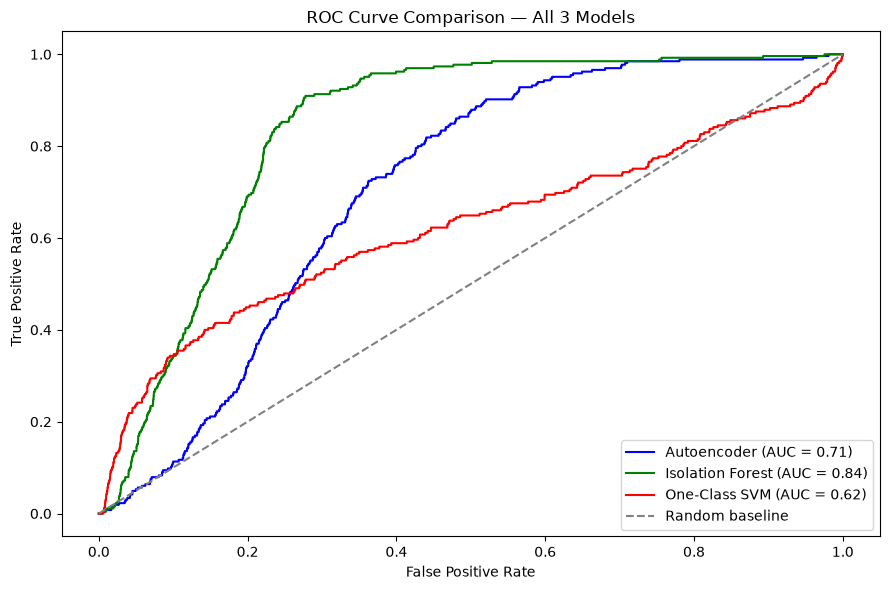


Autoencoder AUC:      0.7053
Isolation Forest AUC: 0.8358
One-Class SVM AUC:    0.6197


In [3]:
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

auc_ae = roc_auc_score(y_test, ae_scores)
auc_if = roc_auc_score(y_test, if_scores)
auc_svm = roc_auc_score(y_test, svm_scores)

plt.figure(figsize=(9, 6))
plt.plot(fpr_ae, tpr_ae, color='blue', label=f'Autoencoder (AUC = {auc_ae:.2f})')
plt.plot(fpr_if, tpr_if, color='green', label=f'Isolation Forest (AUC = {auc_if:.2f})')
plt.plot(fpr_svm, tpr_svm, color='red', label=f'One-Class SVM (AUC = {auc_svm:.2f})')
plt.plot([0,1],[0,1],'--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All 3 Models')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/roc_comparison.png')
plt.show()

print(f"\nAutoencoder AUC:      {auc_ae:.4f}")
print(f"Isolation Forest AUC: {auc_if:.4f}")
print(f"One-Class SVM AUC:    {auc_svm:.4f}")

In [4]:
models = ['Autoencoder', 'Isolation Forest', 'One-Class SVM']
aucs = [auc_ae, auc_if, auc_svm]
best = models[np.argmax(aucs)]

print("="*40)
print("       FINAL MODEL COMPARISON")
print("="*40)
for m, a in zip(models, aucs):
    print(f"{m:<20} AUC = {a:.4f}")
print("="*40)
print(f"Best model: {best}")

       FINAL MODEL COMPARISON
Autoencoder          AUC = 0.7053
Isolation Forest     AUC = 0.8358
One-Class SVM        AUC = 0.6197
Best model: Isolation Forest
